<a href="https://colab.research.google.com/github/AymenShaikh/crops_and_diseases_identification/blob/main/crops_and_diseases_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install kaggle


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


linking with the kaggle via API/JSON token

In [16]:
import json
import os

# Your Kaggle username and token
kaggle_token = "KGAT_dd51cff6b137ce28d4ba6cd24b524ced"
kaggle_username = "Aymen Shaikh"  # replace with your actual Kaggle username

# Create kaggle.json
kaggle_json = {"username": kaggle_username, "key": kaggle_token}

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_json, f)

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

print("kaggle.json created successfully!")

kaggle.json created successfully!


'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [17]:
!kaggle datasets list

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [18]:
!kaggle datasets download -d jawadali1045/20k-multi-class-crop-disease-images

Dataset URL: https://www.kaggle.com/datasets/jawadali1045/20k-multi-class-crop-disease-images
License(s): CC0-1.0
20k-multi-class-crop-disease-images.zip: Skipping, found more recently modified local copy (use --force to force download)


Unzipping the file

In [19]:
!unzip 20k-multi-class-crop-disease-images.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


Exploring the dataset

In [20]:
!ls /content

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [21]:
import os

train_dir = "content/Train"
val_dir = "content/Validation"

# List classes in train folder
classes = os.listdir(train_dir)
print("Classes found:", classes)

# Count images per class
for c in classes:
    class_path = os.path.join(train_dir, c)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{c}: {num_images} images")

Classes found: ['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'bacterial_blight in Cotton', 'Becterial Blight in Rice', 'bollrot on Cotton', 'bollworm on Cotton', 'Brownspot', 'Common_Rust', 'Cotton Aphid', 'cotton mealy bug', 'cotton whitefly', 'Flag Smut', 'Gray_Leaf_Spot', 'Healthy cotton', 'Healthy Maize', 'Healthy Wheat', 'Leaf Curl', 'Leaf smut', 'maize ear rot', 'maize fall armyworm', 'maize stem borer', 'Mosaic sugarcane', 'pink bollworm in cotton', 'red cotton bug', 'RedRot sugarcane', 'RedRust sugarcane', 'Rice Blast', 'Sugarcane Healthy', 'thirps on  cotton', 'Tungro', 'Wheat aphid', 'Wheat black rust', 'Wheat Brown leaf Rust', 'Wheat leaf blight', 'Wheat mite', 'Wheat powdery mildew', 'Wheat scab', 'Wheat Stem fly', 'Wheat___Yellow_Rust', 'Wilt', 'Yellow Rust Sugarcane']
American Bollworm on Cotton: 56 images
Anthracnose on Cotton: 29 images
Army worm: 40 images
bacterial_blight in Cotton: 489 images
Becterial Blight in Rice: 1584 images
bollrot on Co

In [22]:
import os

train_dir = "content/Train"
val_dir = "content/Validation"

print("Train classes:", os.listdir(train_dir))
print("Validation classes:", os.listdir(val_dir))

Train classes: ['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'bacterial_blight in Cotton', 'Becterial Blight in Rice', 'bollrot on Cotton', 'bollworm on Cotton', 'Brownspot', 'Common_Rust', 'Cotton Aphid', 'cotton mealy bug', 'cotton whitefly', 'Flag Smut', 'Gray_Leaf_Spot', 'Healthy cotton', 'Healthy Maize', 'Healthy Wheat', 'Leaf Curl', 'Leaf smut', 'maize ear rot', 'maize fall armyworm', 'maize stem borer', 'Mosaic sugarcane', 'pink bollworm in cotton', 'red cotton bug', 'RedRot sugarcane', 'RedRust sugarcane', 'Rice Blast', 'Sugarcane Healthy', 'thirps on  cotton', 'Tungro', 'Wheat aphid', 'Wheat black rust', 'Wheat Brown leaf Rust', 'Wheat leaf blight', 'Wheat mite', 'Wheat powdery mildew', 'Wheat scab', 'Wheat Stem fly', 'Wheat___Yellow_Rust', 'Wilt', 'Yellow Rust Sugarcane']
Validation classes: ['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'Bacterial Blight in cotton', 'Becterial Blight in Rice', 'bollrot on Cotton', 'bollworm on C

In [23]:
train_classes = set(os.listdir("content/Train"))
val_classes = set(os.listdir("content/Validation"))

print("Only in Train:", train_classes - val_classes)
print("Only in Validation:", val_classes - train_classes)

Only in Train: {'Wheat Brown leaf Rust', 'bacterial_blight in Cotton'}
Only in Validation: {'Wheat Brown leaf rust', 'Bacterial Blight in cotton'}


In [24]:
import shutil
import os

train_dir = "content/Train"
val_dir = "content/Validation"

common_classes = set(os.listdir(train_dir)) & set(os.listdir(val_dir))

# Remove non-common from train
for c in os.listdir(train_dir):
    if c not in common_classes:
        shutil.rmtree(os.path.join(train_dir, c))
        print("Removed from Train:", c)

# Remove non-common from val
for c in os.listdir(val_dir):
    if c not in common_classes:
        shutil.rmtree(os.path.join(val_dir, c))
        print("Removed from Val:", c)

Removed from Train: bacterial_blight in Cotton
Removed from Train: Wheat Brown leaf Rust
Removed from Val: Bacterial Blight in cotton
Removed from Val: Wheat Brown leaf rust


In [25]:
train_dir = "content/Train"
val_dir = "content/Validation"

print(len(os.listdir(train_dir)), os.listdir(train_dir))
print(len(os.listdir(val_dir)), os.listdir(val_dir))

40 ['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'Becterial Blight in Rice', 'bollrot on Cotton', 'bollworm on Cotton', 'Brownspot', 'Common_Rust', 'Cotton Aphid', 'cotton mealy bug', 'cotton whitefly', 'Flag Smut', 'Gray_Leaf_Spot', 'Healthy cotton', 'Healthy Maize', 'Healthy Wheat', 'Leaf Curl', 'Leaf smut', 'maize ear rot', 'maize fall armyworm', 'maize stem borer', 'Mosaic sugarcane', 'pink bollworm in cotton', 'red cotton bug', 'RedRot sugarcane', 'RedRust sugarcane', 'Rice Blast', 'Sugarcane Healthy', 'thirps on  cotton', 'Tungro', 'Wheat aphid', 'Wheat black rust', 'Wheat leaf blight', 'Wheat mite', 'Wheat powdery mildew', 'Wheat scab', 'Wheat Stem fly', 'Wheat___Yellow_Rust', 'Wilt', 'Yellow Rust Sugarcane']
40 ['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'Becterial Blight in Rice', 'bollrot on Cotton', 'bollworm on Cotton', 'Brownspot', 'Common_Rust', 'Cotton Aphid', 'cotton mealy bug', 'cotton whitefly', 'Flag Smut', 'Gray_Leaf

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dir = "content/Train"
val_dir = "content/Validation"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


Found 14868 images belonging to 40 classes.
Found 2872 images belonging to 40 classes.


In [27]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights="imagenet", include_top=False,
                         input_shape=(224,224,3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
output = Dense(train_gen.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 51s 5us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 338,216 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Running Epochs on whole dataset

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10
110/465 ━━━━━━━━━━━━━━━━━━━━ 15:04 3s/step - accuracy: 0.5397 - loss: 1.8330

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:1000: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7033 - loss: 1.1282

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:890: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


465/465 ━━━━━━━━━━━━━━━━━━━━ 1443s 3s/step - accuracy: 0.7993 - loss: 0.7291 - val_accuracy: 0.7528 - val_loss: 0.9525
Epoch 2/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 1166s 3s/step - accuracy: 0.8890 - loss: 0.3557 - val_accuracy: 0.8029 - val_loss: 0.7767
Epoch 3/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 1352s 3s/step - accuracy: 0.9168 - loss: 0.2576 - val_accuracy: 0.7893 - val_loss: 0.8465
Epoch 4/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 1122s 2s/step - accuracy: 0.9276 - loss: 0.2241 - val_accuracy: 0.8430 - val_loss: 0.6835
Epoch 5/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 1024s 2s/step - accuracy: 0.9392 - loss: 0.1872 - val_accuracy: 0.8402 - val_loss: 0.7319
Epoch 6/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 1120s 2s/step - accuracy: 0.9448 - loss: 0.1664 - val_accuracy: 0.8350 - val_loss: 0.7373
Epoch 7/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 957s 2s/step - accuracy: 0.9510 - loss: 0.1527 - val_accuracy: 0.8545 - val_loss: 0.6901
Epoch 8/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 5672s 12s/step - accuracy: 0.9541 - loss: 0.1385 - val_accurac

saving the model

In [ ]:
model.save("plant_disease_model.keras")
print("Model saved!")

Model saved!


Graph plotting

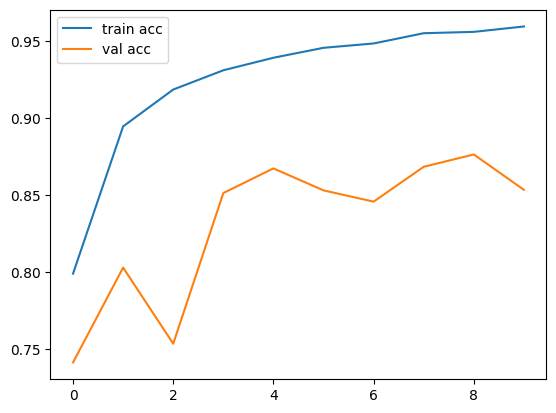

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.show()

Fine Tuning

In [ ]:
import tensorflow as tf
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=2
)

Epoch 1/2
151/465 ━━━━━━━━━━━━━━━━━━━━ 11:18 2s/step - accuracy: 0.6501 - loss: 1.3500

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7565 - loss: 0.8877

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 0. 
  warnings.warn(str(msg))


465/465 ━━━━━━━━━━━━━━━━━━━━ 1145s 2s/step - accuracy: 0.7567 - loss: 0.8869 - val_accuracy: 0.8444 - val_loss: 0.8055
Epoch 2/2
465/465 ━━━━━━━━━━━━━━━━━━━━ 1122s 2s/step - accuracy: 0.9296 - loss: 0.2181 - val_accuracy: 0.8555 - val_loss: 0.7036


saving finetuned model

In [ ]:
model.save("/content/crop_disease_finetuned.keras")
print("Finetuned Model saved!")

Finetuned Model saved!


Epochs on specific crop "Crop"

In [ ]:
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model

IMG_SIZE = (224,224)
BATCH = 32

# Use your actual dataset paths
train_dir = "content/Train"
val_dir   = "content/Validation"

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical"
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical"
)

# Build model
base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
out = Dense(train_gen.num_classes, activation="softmax")(x)

crop_model = Model(base.input, out)
crop_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train
crop_model.fit(train_gen, validation_data=val_gen, epochs=10)

# Save model
crop_model.save("crop_model.h5")
print("Model saved successfully!")

Found 14868 images belonging to 40 classes.
Found 2872 images belonging to 40 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 866s 2s/step - accuracy: 0.6600 - loss: 1.2726 - val_accuracy: 0.7674 - val_loss: 0.9066
Epoch 2/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 846s 2s/step - accuracy: 0.9243 - loss: 0.2904 - val_accuracy: 0.8350 - val_loss: 0.7246
Epoch 3/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 845s 2s/step - accuracy: 0.9513 - loss: 0.1914 - val_accuracy: 0.8621 - val_loss: 0.6281
Epoch 4/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 857s 2s/step - accuracy: 0.9685 - loss: 0.1343 - val_accuracy: 0.8656 - val_loss: 0.6637
Epoch 5/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 849s 2s/step - accuracy: 0.9763 - loss: 0.1040 - val_accuracy: 0.8872 - val_loss: 0.5773
Epoch 6/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 850s 2s/step - accuracy: 0.9848 - loss: 0.0770 - val_accuracy: 0.8764 - val_loss: 0.6206
Epoch 7/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 867s 2s/step - accuracy: 0.9883 - loss: 0.0634 - val_accuracy: 0.8980 - val_loss: 0.5748
Epoch 8/10
465/465 ━━━━━━━━━━━━━━━━━━━━ 855s 2s/step - accuracy: 0.9895 - loss: 0.0539 - val_accu

Model saved successfully!


faster version for wheat

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

IMG_SIZE = (160,160)

train_dir = "content/Train"
val_dir = "content/Validation"

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=64, class_mode="categorical"
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=64, class_mode="categorical"
)

base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(160,160,3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
out = Dense(train_gen.num_classes, activation="softmax")(x)

disease_model = Model(base.input, out)
disease_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

early = EarlyStopping(patience=2, restore_best_weights=True)

disease_model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early])

disease_model.save("wheat_disease_model.h5")

Found 14868 images belonging to 40 classes.
Found 2872 images belonging to 40 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 498s 2s/step - accuracy: 0.6074 - loss: 1.5005 - val_accuracy: 0.7228 - val_loss: 1.0492
Epoch 2/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 534s 2s/step - accuracy: 0.9138 - loss: 0.3310 - val_accuracy: 0.8165 - val_loss: 0.7643
Epoch 3/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 485s 2s/step - accuracy: 0.9513 - loss: 0.2115 - val_accuracy: 0.8618 - val_loss: 0.6404
Epoch 4/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.9619 - loss: 0.1605 - val_accuracy: 0.8625 - val_loss: 0.6587
Epoch 5/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.9741 - loss: 0.1205 - val_accuracy: 0.8774 - val_loss: 0.5977
Epoch 6/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 485s 2s/step - accuracy: 0.9811 - loss: 0.0952 - val_accuracy: 0.8935 - val_loss: 0.5728
Epoch 7/10
233/233 ━━━━━━━━━━━━━━━━━━━━ 533s 2s/step - accuracy: 0.9854 - loss: 0.0758 - v

In [ ]:
import os
os.listdir(".")

['.config',
 'Train',
 '20k-multi-class-crop-disease-images.zip',
 'plant_disease_model.keras',
 'wheat_disease_model.h5',
 'crop_disease_finetuned.keras',
 'Validation',
 'crop_model.h5',
 'sample_data']

cropwise dataset creation

In [ ]:
import os, shutil

base_train = "content/Train"
base_val   = "content/Validation"

crops = {
    "wheat": ["Wheat"],
    "maize": ["maize", "Maize"],
    "rice": ["Rice", "Tungro"],
    "sugarcane": ["sugarcane", "Sugarcane"]
}

for crop in crops:
    os.makedirs(f"{crop}_dataset/train", exist_ok=True)
    os.makedirs(f"{crop}_dataset/val", exist_ok=True)

def move_classes(src, dest, keywords):
    for cls in os.listdir(src):
        for key in keywords:
            if key.lower() in cls.lower():
                shutil.copytree(
                    os.path.join(src, cls),
                    os.path.join(dest, cls),
                    dirs_exist_ok=True
                )

for crop, keys in crops.items():
    move_classes(base_train, f"{crop}_dataset/train", keys)
    move_classes(base_val,   f"{crop}_dataset/val",   keys)

print("Crop-wise datasets created!")

Crop-wise datasets created!


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

IMG_SIZE = (160,160)   # smaller = faster
BATCH = 64             # faster

def train_crop_model(crop_name):
    train_dir = f"{crop_name}_dataset/train"
    val_dir   = f"{crop_name}_dataset/val"

    train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical"
    )

    val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        val_dir, target_size=IMG_SIZE, batch_size=BATCH, class_mode="categorical"
    )

    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=(160,160,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    out = Dense(train_gen.num_classes, activation="softmax")(x)

    model = Model(base.input, out)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

    model.fit(train_gen, validation_data=val_gen, epochs=5)

    model.save(f"{crop_name}_disease_model.keras")
    print(f"{crop_name} model saved!")

training all crops together (faster version)

In [ ]:
train_crop_model("wheat")
train_crop_model("maize")
train_crop_model("rice")
train_crop_model("sugarcane")

Found 1433 images belonging to 9 classes.
Found 360 images belonging to 9 classes.
Epoch 1/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 96s 4s/step - accuracy: 0.2320 - loss: 2.2627 - val_accuracy: 0.5694 - val_loss: 1.3214
Epoch 2/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.7009 - loss: 0.9673 - val_accuracy: 0.6722 - val_loss: 0.9987
Epoch 3/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.7934 - loss: 0.7157 - val_accuracy: 0.7583 - val_loss: 0.8440
Epoch 4/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.8498 - loss: 0.5670 - val_accuracy: 0.7611 - val_loss: 0.7510
Epoch 5/5
23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.8850 - loss: 0.4772 - val_accuracy: 0.7944 - val_loss: 0.6962
wheat model saved!
Found 1480 images belonging to 4 classes.
Found 426 images belonging to 4 classes.
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - accuracy: 0.7653 - loss: 0.6561 - val_accuracy: 0.8146 - val_loss: 0.4693
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.92

In [ ]:
import os
os.listdir(".")

['.config',
 'maize_disease_model.keras',
 'wheat_disease_model.keras',
 'Train',
 'sugarcane_disease_model.keras',
 '20k-multi-class-crop-disease-images.zip',
 'maize_dataset',
 'plant_disease_model.keras',
 'wheat_disease_model.h5',
 'crop_disease_finetuned.keras',
 'Validation',
 'crop_model.h5',
 'wheat_dataset',
 'sugarcane_dataset',
 'rice_disease_model.keras',
 'rice_dataset',
 'sample_data']

Uploading 5 files at once

In [ ]:
!pip install opencv-python

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bacterial_blight_rice.webp to bacterial_blight_rice.webp
Saving healthy wheat.jpg to healthy wheat (1).jpg
Saving healthy_sugarcane.jpg to healthy_sugarcane (1).jpg
Saving maize_stem_borer.webp to maize_stem_borer (1).webp
Saving redrust_sugarcane.webp to redrust_sugarcane.webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_5']
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)


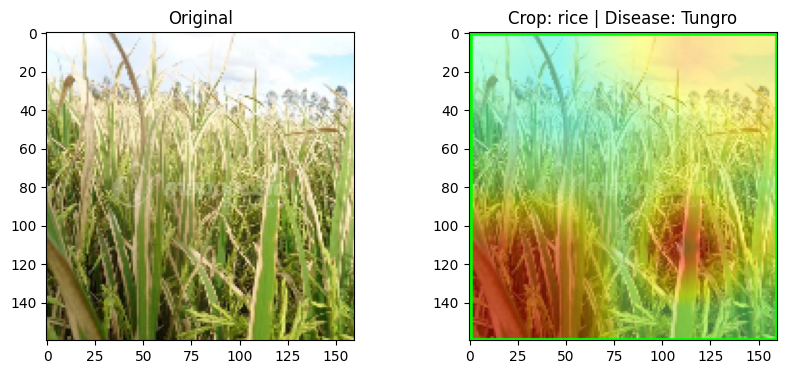

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)


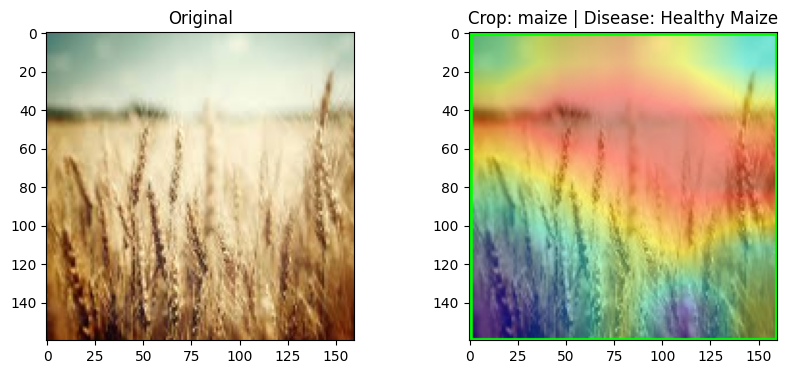

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_6']
Received: inputs=Tensor(shape=(1, 160, 160, 3))
  warnings.warn(msg)


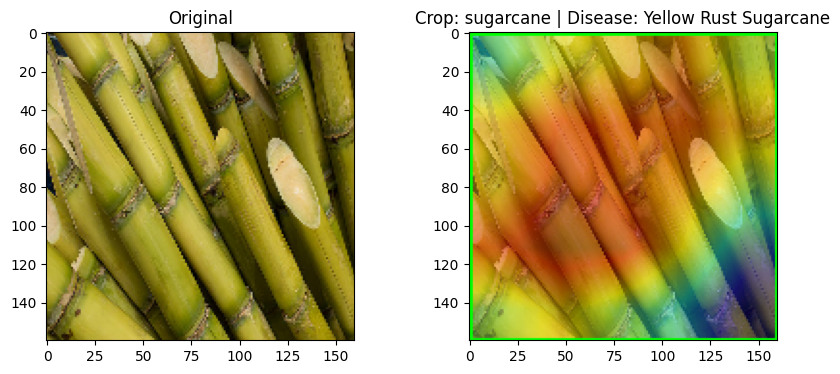

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


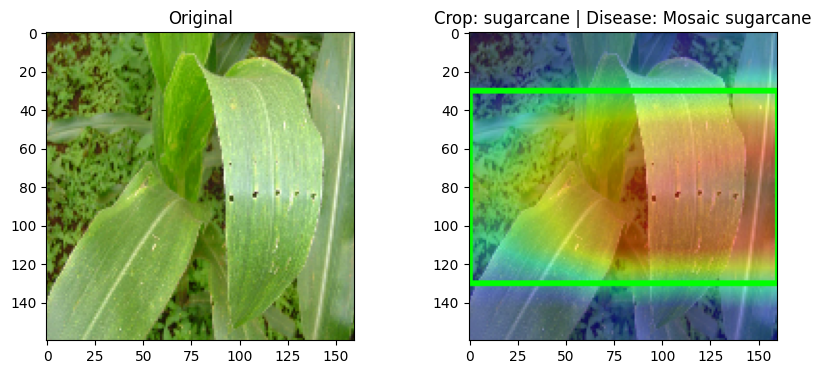

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


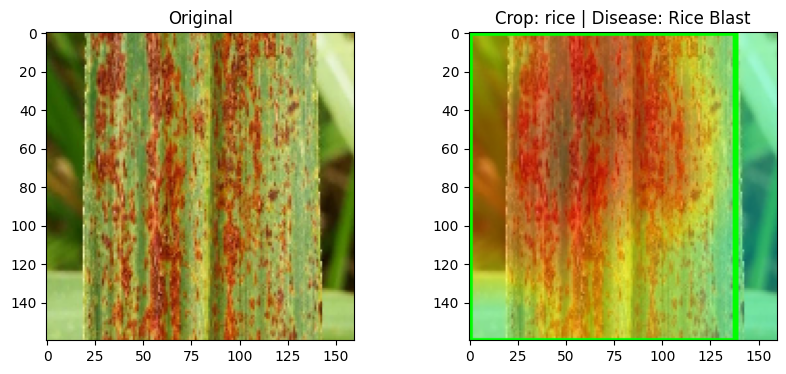

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load models
models = {
    "wheat": tf.keras.models.load_model("wheat_disease_model.keras"),
    "maize": tf.keras.models.load_model("maize_disease_model.keras"),
    "rice": tf.keras.models.load_model("rice_disease_model.keras"),
    "sugarcane": tf.keras.models.load_model("sugarcane_disease_model.keras"),
}

datasets = {
    "wheat": "wheat_dataset/train",
    "maize": "maize_dataset/train",
    "rice": "rice_dataset/train",
    "sugarcane": "sugarcane_dataset/train",
}

last_conv_layer_name = "Conv_1"

def make_gradcam_heatmap(img_array, model):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)
    return heatmap.numpy()

def predict_crop_and_disease(img_path):
    img = image.load_img(img_path, target_size=(160,160))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    best_crop = None
    best_conf = 0
    best_model = None
    best_pred = None

    for crop, model in models.items():
        pred = model.predict(img_array)
        conf = np.max(pred)
        if conf > best_conf:
            best_conf = conf
            best_crop = crop
            best_model = model
            best_pred = pred

    class_names = sorted(os.listdir(datasets[best_crop]))
    disease = class_names[np.argmax(best_pred)]

    heatmap = make_gradcam_heatmap(img_array, best_model)

    img_cv = cv2.imread(img_path)
    img_cv = cv2.resize(img_cv, (160,160))

    heatmap_resized = cv2.resize(heatmap, (160,160))
    heatmap_colored = cv2.applyColorMap(np.uint8(255*heatmap_resized), cv2.COLORMAP_JET)

    superimposed = cv2.addWeighted(img_cv, 0.6, heatmap_colored, 0.4, 0)

    thresh = np.uint8(255 * heatmap_resized)
    _, binary = cv2.threshold(thresh, 120, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        x,y,w,h = cv2.boundingRect(c)
        cv2.rectangle(superimposed, (x,y), (x+w,y+h), (0,255,0), 2)

    return img_cv, superimposed, best_crop, disease

# Run on all uploaded images
for img_name in uploaded.keys():
    path = "/content/" + img_name
    original, result, crop, disease = predict_crop_and_disease(path)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f"Crop: {crop} | Disease: {disease}")

    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp wheat_disease_model.keras /content/drive/MyDrive/
!cp maize_disease_model.keras /content/drive/MyDrive/
!cp rice_disease_model.keras /content/drive/MyDrive/
!cp sugarcane_disease_model.keras /content/drive/MyDrive/

Mounted at /content/drive
